## 环境配置

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import os
from torchvision.transforms import InterpolationMode
from thop import profile
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

## 数据预处理

In [2]:
img_size = 224
norm_mean = [0.210, 0.210, 0.210]
norm_std = [0.182, 0.182, 0.182]

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((img_size, img_size), interpolation=InterpolationMode.BICUBIC),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15), 
        transforms.ColorJitter(brightness=0.2, contrast=0.2), 
        transforms.ToTensor(),
        transforms.Normalize(norm_mean, norm_std),
        transforms.RandomErasing(p=0.4)      
    ]),
    'val': transforms.Compose([
        transforms.Resize((img_size, img_size), interpolation=InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(norm_mean, norm_std)
    ]),
    'test': transforms.Compose([
        transforms.Resize((img_size, img_size), interpolation=InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(norm_mean, norm_std)
    ]),
}

data_dir = 'RetinalOCT_Dataset'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['train', 'val', 'test']}

dataloaders = {
    x: DataLoader(
        image_datasets[x], 
        batch_size=64, 
        shuffle=(x == 'train'), 
        num_workers=4,       
        pin_memory=True,               
        persistent_workers=True,       
        prefetch_factor=4
    )
    for x in ['train', 'val', 'test']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"设备: {device}")
print(f"类别：{class_names}")
print("训练/验证/测试集数量:", dataset_sizes)

设备: cpu
类别：['AMD', 'CNV', 'CSR', 'DME', 'DR', 'DRUSEN', 'MH', 'NORMAL']
训练/验证/测试集数量: {'train': 18400, 'val': 2800, 'test': 2800}


## CNN搭建

In [3]:
# SE 注意力模块
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)  
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)  
        y = self.fc(y).view(b, c, 1, 1)
        return x * y

In [4]:
# ConvNeXtBlock
class ConvNeXtBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        # 深度可分离卷积 (Depthwise Conv)
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)
        # 这里改用 GroupNorm 代替 LayerNorm，效果近似且速度快
        self.norm = nn.GroupNorm(num_groups=1, num_channels=dim) 
        # 1x1 卷积代替 Linear，避免 permute
        self.pwconv1 = nn.Conv2d(dim, 4 * dim, kernel_size=1) 
        self.act = nn.GELU()
        self.pwconv2 = nn.Conv2d(4 * dim, dim, kernel_size=1)

    def forward(self, x):
        residual = x
        x = self.dwconv(x)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)
        return residual + x

In [5]:
class OCTNet(nn.Module):
    def __init__(self, num_classes=8):
        super(OCTNet, self).__init__()

        def simple_block(in_ch, out_ch, use_se=False):
            layers = []
            # 如果通道数变化，先用一个 1x1 卷积调整通道
            if in_ch != out_ch:
                layers.append(nn.Conv2d(in_ch, out_ch, kernel_size=1))
            
            # 核心：ConvNeXt Block
            layers.append(ConvNeXtBlock(out_ch))
            
            # 可选：SE Block
            if use_se:
                layers.append(SEBlock(out_ch))
            
            # 下采样
            layers.append(nn.MaxPool2d(2))
            return nn.Sequential(*layers)

        self.features = nn.Sequential(
            # Stage 1: 浅层特征，不用 SE，保持简单
            simple_block(3, 32, use_se=False),
            # Stage 2
            simple_block(32, 64, use_se=False),
            # Stage 3
            simple_block(64, 128, use_se=True),
            # Stage 4
            simple_block(128, 256, use_se=True),
            # Stage 5
            simple_block(256, 512, use_se=True),
        )

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 1024),
            nn.GELU(),
            nn.Dropout(0.5), 
            nn.Linear(1024, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

model = OCTNet(num_classes=8).to(device)

In [ ]:
inputs = torch.randn(1, 3, 224, 224).float()
flops, params = profile(model, inputs=(inputs, ))
print('FLOPs: {:.2f} G'.format(flops / 1e9))
print('Params: {:.2f} M'.format(params / 1e6))

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.dropout.Dropout'>.
FLOPs: 2.32 G
Params: 3.60 M


## 定义损失函数与优化器

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing = 0.1)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=3e-5
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20,
    eta_min=1e-6
)

scaler = torch.amp.GradScaler('cuda')

## 训练与验证循环

In [17]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=30):

    best_acc = 0.0
    best_wts = None
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'\n=========== Epoch {epoch+1}/{num_epochs} ===========')

        for phase in ['train', 'val']:
            model.train() if phase=='train' else model.eval()

            running_loss = 0.0
            running_corrects = 0

            pbar = tqdm(dataloaders[phase], desc=f"{phase} {epoch+1}")

            for inputs, labels in pbar:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # 混合精度
                with torch.set_grad_enabled(phase == 'train'):
                    with torch.amp.autocast('cuda'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                    if phase == 'train':
                        scaler.scale(loss).backward()
                        scaler.step(optimizer)
                        scaler.update()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc  = running_corrects.double() / dataset_sizes[phase]

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == 'train':
                scheduler.step()

            else:
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_wts = model.state_dict()

    print(f"\n训练完成！最佳验证准确率: {best_acc:.4f}")
    model.load_state_dict(best_wts)
    return model, history

model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=20)


=========== Epoch 1/20 ===========


train 1: 100%|██████████| 288/288 [02:26<00:00,  1.97it/s]


train Loss: 1.5115 Acc: 0.3945


val 1: 100%|██████████| 44/44 [00:12<00:00,  3.42it/s]


val Loss: 1.4313 Acc: 0.4521

=========== Epoch 2/20 ===========


...

val Loss: 0.5442 Acc: 0.9654

=========== Epoch 20/20 ===========


train 20: 100%|██████████| 288/288 [02:25<00:00,  1.98it/s]


train Loss: 0.5672 Acc: 0.9543


val 20: 100%|██████████| 44/44 [00:10<00:00,  4.06it/s]

val Loss: 0.5442 Acc: 0.9629

训练完成！最佳验证准确率: 0.9664


## 结果可视化与测试集评估

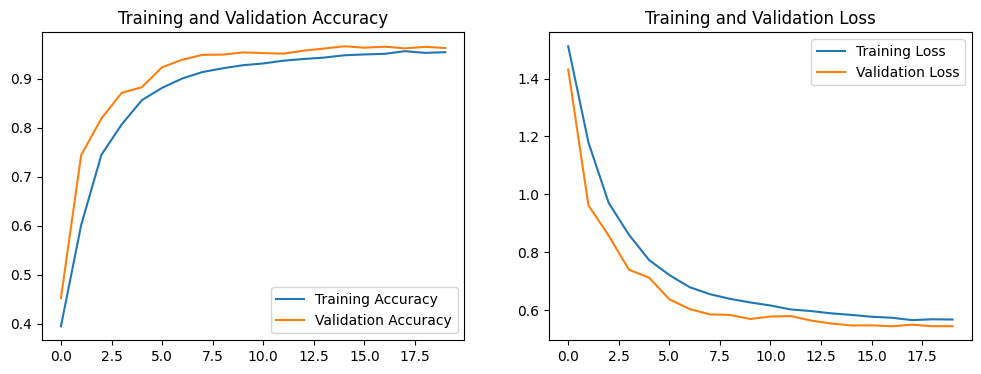

In [18]:
# 绘制 Loss 和 Accuracy 曲线
def plot_training_history(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    
    # 准确率曲线
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # Loss 曲线
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

plot_training_history(history)

----------------------------------------------------------------
分类报告 (Classification Report):
              precision    recall  f1-score   support

         AMD     1.0000    1.0000    1.0000       350
         CNV     0.9371    0.9371    0.9371       350
         CSR     1.0000    1.0000    1.0000       350
         DME     0.9528    0.9229    0.9376       350
          DR     1.0000    1.0000    1.0000       350
      DRUSEN     0.9419    0.9257    0.9337       350
          MH     1.0000    1.0000    1.0000       350
      NORMAL     0.9319    0.9771    0.9540       350

    accuracy                         0.9704      2800
   macro avg     0.9705    0.9704    0.9703      2800
weighted avg     0.9705    0.9704    0.9703      2800

----------------------------------------------------------------


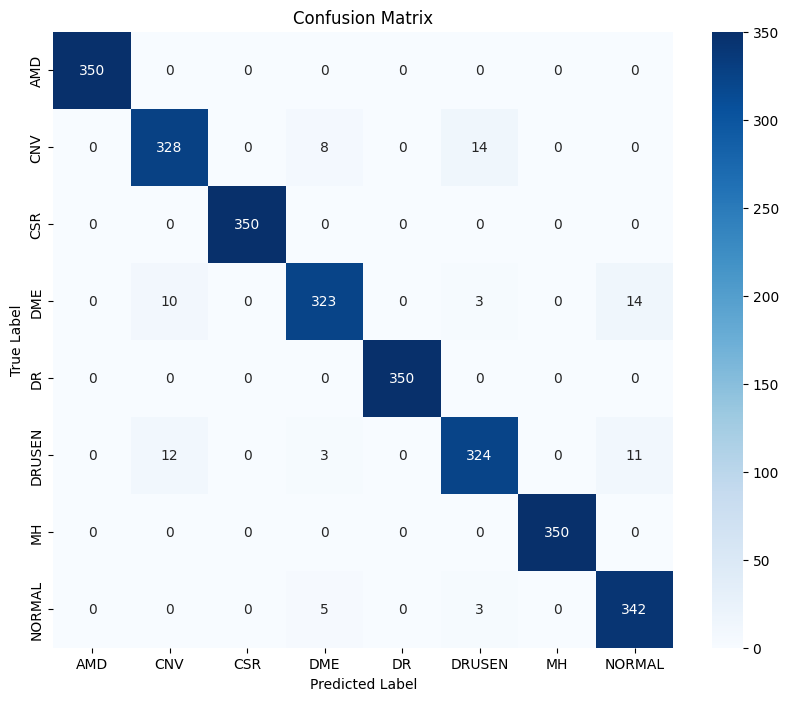

Test Set Global Accuracy: 0.9704


In [ ]:
# 测试集评估与混淆矩阵
def evaluate_test_set(model, dataloader, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    # 1. 预测过程
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # 2. 生成分类报告 
    print("分类报告 (Classification Report):")
    report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
    print(report)

    # 3. 绘制混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()
    
    # 4. 计算总准确率
    accuracy = np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
    print(f'Test Set Global Accuracy: {accuracy:.4f}')

evaluate_test_set(model, dataloaders['test'], class_names)